In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
from google.colab import files
uploaded = files.upload()

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

Saving insurance.csv to insurance.csv


In [5]:
# Load your messy file
df = pd.read_csv('insurance.csv')

# Look at the first 5 rows to see what you are dealing with
print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [8]:
df.drop_duplicates(inplace=True)
df.dropna( inplace=True)


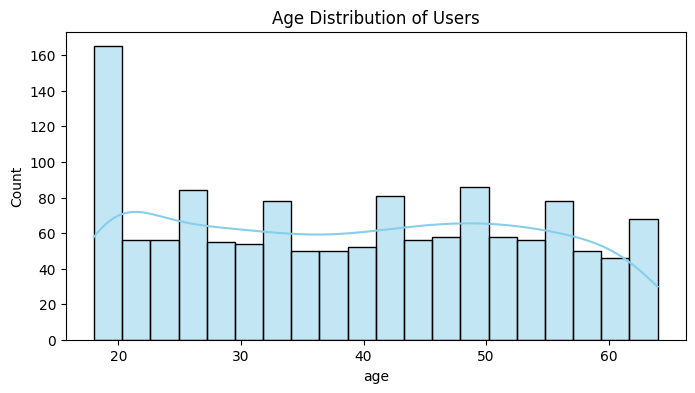

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Users')
plt.xlabel('age')
plt.ylabel('Count')
plt.show()


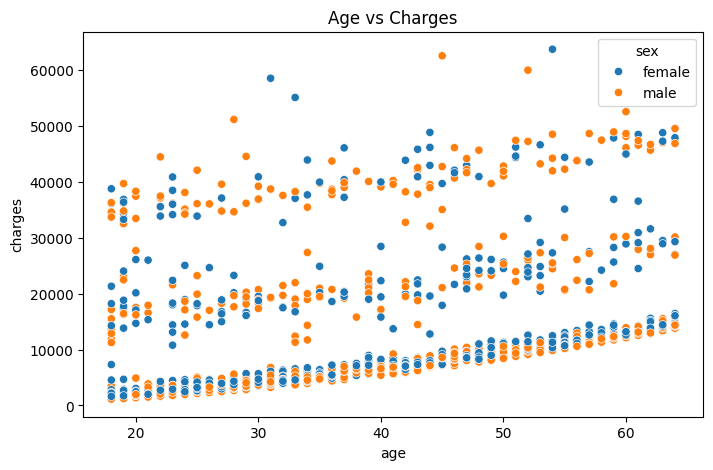

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='sex')
plt.title('Age vs Charges')
plt.xlabel('age')
plt.ylabel('charges')
plt.show()


/tmp/ipykernel_646/1839002277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='Set2')


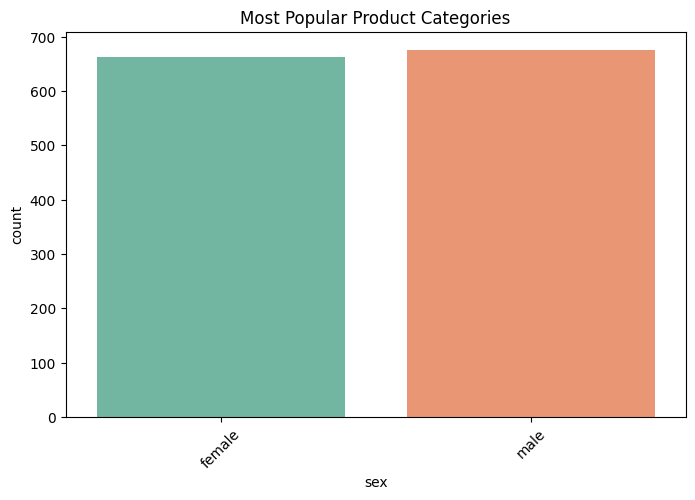

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='Set2')
plt.title('Most Popular Product Categories')
plt.xticks(rotation=45) # Tilt words so they don't overlap
plt.show()


In [23]:
from sklearn.model_selection import train_test_split

# Convert categorical features to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Separate features (X - columns used to predict) from the target (y - what we want to predict)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# Split: 80% for learning (training), 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

Training samples: 1069 | Testing samples: 268


In [25]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model (now a Regressor)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using our training data
model.fit(X_train, y_train)

# Make predictions on the unseen test data
y_pred = model.predict(X_test)
# For regression, there is no predict_proba, y_pred directly gives the predicted values.

Mean Absolute Error (MAE): 2637.99
Mean Squared Error (MSE): 22113000.54
Root Mean Squared Error (RMSE): 4702.45
R-squared (R2): 0.88


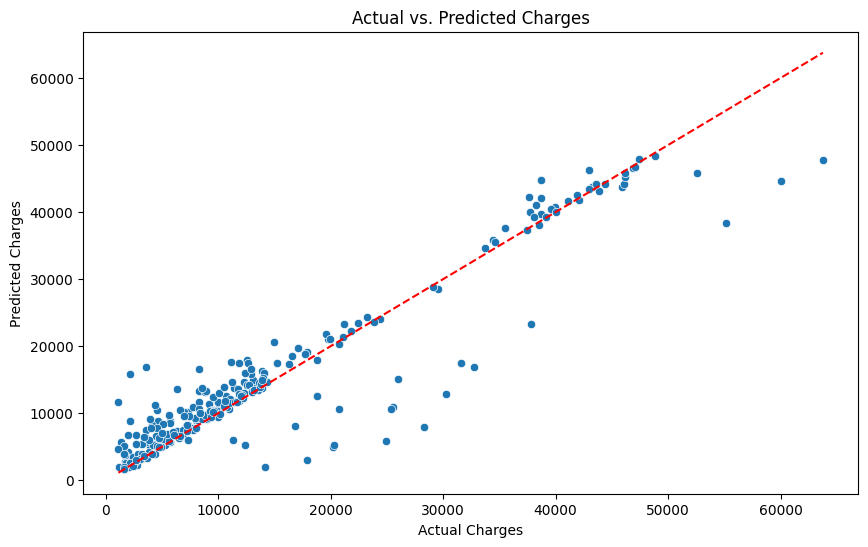

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics for regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Charges')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression

# Swap this in Phase 3 to see if a simple linear line performs better!
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()